In [1]:
# Nguyễn Hoàng Tùng
# Bài 1.1 - Xây dựng mô hình LSTM (Model 1 - không dropout)

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1️⃣ Đọc dữ liệu
data_path = "C:/DATA/e_com_tungnh.csv"
df = pd.read_csv(data_path)

print("Kích thước dữ liệu:", df.shape)
print(df.head())

# 2️⃣ Giả sử cột cuối là nhãn (label), còn lại là đặc trưng (features)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# 3️⃣ Chuẩn hóa dữ liệu (LSTM nhạy cảm với tỉ lệ dữ liệu)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 4️⃣ Chuyển đổi dữ liệu thành dạng 3D cho LSTM: (samples, timesteps, features)
# Nếu dữ liệu không theo chuỗi thời gian, coi mỗi mẫu là 1 timestep
X_reshaped = np.reshape(X_scaled, (X_scaled.shape[0], 1, X_scaled.shape[1]))

# 5️⃣ Xây dựng mô hình LSTM Model 1 (không dropout)
model1 = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_reshaped.shape[1], X_reshaped.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(32, return_sequences=False),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # sigmoid cho bài toán nhị phân
])

# 6️⃣ Compile mô hình
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7️⃣ Xem tóm tắt mô hình
model1.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

Kích thước dữ liệu: (40019, 3)
   userId  itemId                                        review_text
0       1     215  đáng tiền tận tình giao hàng đổi trả hài lòng ...
1       1      93  đẹp không tốt rất đổi trả không xấu chậm đẹp g...
2       1     213  đáng tiền đóng gói không đáng tiền không tận tình
3       1     333  tận tình giá chậm không đáng tiền xấu rất khôn...
4       1      32            thất vọng hài lòng ưu đãi tận tình chậm


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 128)              │          67,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 1, 64)               │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 129,441 (505.63 KB)

 Trainable params: 129,441 (505.63 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
# Nguyễn Hoàng Tùng
# Bài 1.2 - Xây dựng mô hình Model 2 (có dropout = 0.2)

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1️⃣ Đọc dữ liệu
data_path = "C:/DATA/e_com_tungnh.csv"
df = pd.read_csv(data_path)

# Giả sử cột cuối là nhãn (label)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# 2️⃣ Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3️⃣ Chuyển đổi về dạng 3D cho LSTM
X_reshaped = np.reshape(X_scaled, (X_scaled.shape[0], 1, X_scaled.shape[1]))

# 4️⃣ Xây dựng mô hình Model 2 (thêm dropout = 0.2)
model2 = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_reshaped.shape[1], X_reshaped.shape[2])),
    Dropout(0.2),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 5️⃣ Compile mô hình
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6️⃣ Xem cấu trúc mô hình
model2.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 1, 128)              │          67,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 1, 64)               │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 129,441 (505.63 KB)

 Trainable params: 129,441 (505.63 KB)

 Non-trainable params: 0 (0.00 B)

Dữ liệu mẫu:
   userId  itemId                                        review_text category
0       1     215  đáng tiền tận tình giao hàng đổi trả hài lòng ...   laptop
1       1      93  đẹp không tốt rất đổi trả không xấu chậm đẹp g...  clothes
2       1     213  đáng tiền đóng gói không đáng tiền không tận tình  clothes
3       1     333  tận tình giá chậm không đáng tiền xấu rất khôn...   laptop
4       1      32            thất vọng hài lòng ưu đãi tận tình chậm  clothes
Epoch 1/10


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1001/1001 ━━━━━━━━━━━━━━━━━━━━ 98s 94ms/step - accuracy: 0.1680 - loss: -130.9327 - val_accuracy: 0.1682 - val_loss: -358.3453
Epoch 2/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 97s 97ms/step - accuracy: 0.1681 - loss: -764.1541 - val_accuracy: 0.1682 - val_loss: -1252.1743
Epoch 3/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 95s 95ms/step - accuracy: 0.1681 - loss: -1883.1691 - val_accuracy: 0.1682 - val_loss: -2579.2407
Epoch 4/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 99s 99ms/step - accuracy: 0.1681 - loss: -3387.7290 - val_accuracy: 0.1682 - val_loss: -4254.0503
Epoch 5/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 129s 129ms/step - accuracy: 0.1681 - loss: -5226.1953 - val_accuracy: 0.1682 - val_loss: -6254.2036
Epoch 6/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 113s 113ms/step - accuracy: 0.1681 - loss: -7381.4478 - val_accuracy: 0.1682 - val_loss: -8560.8770
Epoch 7/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 109s 109ms/step - accuracy: 0.1681 - loss: -9843.8379 - val_accuracy: 0.1682 - val_loss: -11176.5684
Epoch 8/10
1001/1001 ━━━━━━

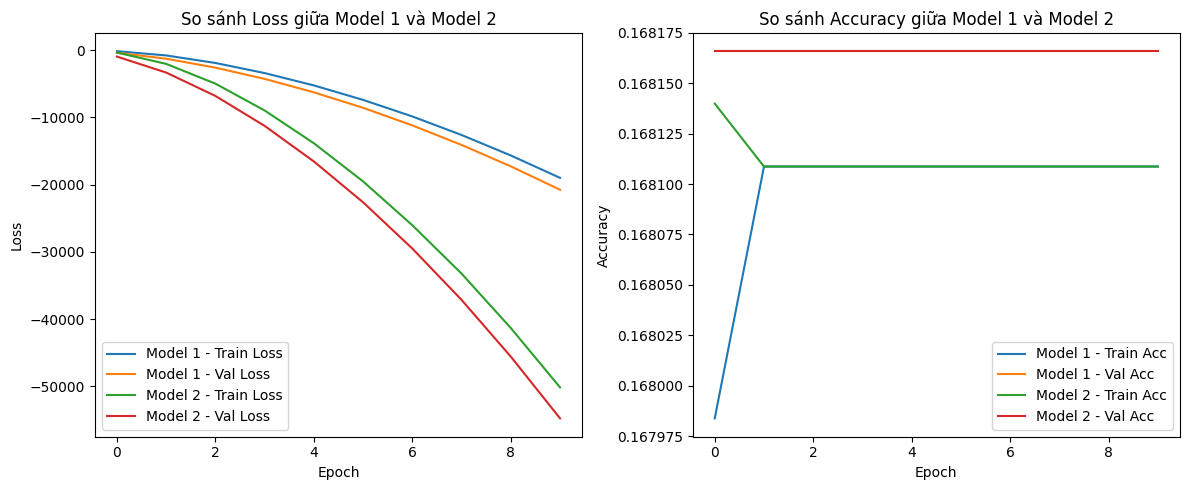

In [6]:
# Nguyễn Hoàng Tùng
# Bài 1.3 - LSTM dự đoán category (laptop / clothes) từ review_text

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 1️⃣ Đọc dữ liệu
data_path = "C:/DATA/e_com_tungnh.csv"  # file có cột: userId, itemId, review_text, category
df = pd.read_csv(data_path)

print("Dữ liệu mẫu:")
print(df.head())

# 2️⃣ Mã hóa nhãn (category)
# Laptop = 0, Clothes = 1
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])
y = df['label'].values

# 3️⃣ Chuẩn bị dữ liệu văn bản
texts = df['review_text'].astype(str).values

# 4️⃣ Tokenize và padding
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

maxlen = 100  # độ dài tối đa của review
X = pad_sequences(sequences, maxlen=maxlen, padding='post')

# 5️⃣ Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6️⃣ Model 1 - không dropout
model1 = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=maxlen),
    LSTM(128, return_sequences=True),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # dự đoán nhị phân: laptop (0) hoặc clothes (1)
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7️⃣ Model 2 - có dropout = 0.2
model2 = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=maxlen),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 8️⃣ Huấn luyện cả hai mô hình
history1 = model1.fit(X_train, y_train, epochs=10, batch_size=32,
                      validation_data=(X_test, y_test), verbose=1)

history2 = model2.fit(X_train, y_train, epochs=10, batch_size=32,
                      validation_data=(X_test, y_test), verbose=1)

# 9️⃣ Vẽ biểu đồ so sánh loss và accuracy
plt.figure(figsize=(12,5))

# --- LOSS ---
plt.subplot(1,2,1)
plt.plot(history1.history['loss'], label='Model 1 - Train Loss')
plt.plot(history1.history['val_loss'], label='Model 1 - Val Loss')
plt.plot(history2.history['loss'], label='Model 2 - Train Loss')
plt.plot(history2.history['val_loss'], label='Model 2 - Val Loss')
plt.title('So sánh Loss giữa Model 1 và Model 2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# --- ACCURACY ---
plt.subplot(1,2,2)
plt.plot(history1.history['accuracy'], label='Model 1 - Train Acc')
plt.plot(history1.history['val_accuracy'], label='Model 1 - Val Acc')
plt.plot(history2.history['accuracy'], label='Model 2 - Train Acc')
plt.plot(history2.history['val_accuracy'], label='Model 2 - Val Acc')
plt.title('So sánh Accuracy giữa Model 1 và Model 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [7]:
# Nguyễn Hoàng Tùng
# Bài 1.5 - Tính sai số và so sánh model 1 & model 2

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1️⃣ Dự đoán với 2 model
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

# 2️⃣ Tính các sai số
mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
rmse1 = np.sqrt(mse1)

mae2 = mean_absolute_error(y_test, y_pred2)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)

# 3️⃣ In kết quả
print("📊 Kết quả sai số:")
print(f"Model 1 (Không Dropout):  MAE = {mae1:.4f},  MSE = {mse1:.4f},  RMSE = {rmse1:.4f}")
print(f"Model 2 (Dropout=0.2):    MAE = {mae2:.4f},  MSE = {mse2:.4f},  RMSE = {rmse2:.4f}")


251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step
📊 Kết quả sai số:
Model 1 (Không Dropout):  MAE = 1.7620,  MSE = 4.8067,  RMSE = 2.1924
Model 2 (Dropout=0.2):    MAE = 1.7620,  MSE = 4.8067,  RMSE = 2.1924


In [19]:
# Nguyễn Hoàng Tùng
# Bài 2.1

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

# Đường dẫn thư mục gốc và thư mục lưu ảnh augmented
root_dir = r"C:/DATA"
output_dir = os.path.join(root_dir, "hoa_aug")

# Tạo thư mục đích nếu chưa có
os.makedirs(output_dir, exist_ok=True)

# Các thư mục con (loại hoa)
flower_dirs = ["hoaHong", "hoaCamTuCau"]

# Cấu hình augmentation
datagen = ImageDataGenerator(
    rotation_range=40,       # Xoay ngẫu nhiên trong khoảng 40 độ
    width_shift_range=0.2,   # Dịch ngang
    height_shift_range=0.2,  # Dịch dọc
    shear_range=0.2,         # Biến dạng xiên
    zoom_range=0.2,          # Phóng to / thu nhỏ
    horizontal_flip=True,    # Lật ngang
    fill_mode='nearest'      # Cách điền pixel khi biến dạng
)

# Duyệt qua từng thư mục hoa
for folder in flower_dirs:
    src_path = os.path.join(root_dir, folder)
    dest_path = os.path.join(output_dir, folder)
    os.makedirs(dest_path, exist_ok=True)

    for filename in os.listdir(src_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(src_path, filename)
            img = load_img(img_path)
            x = img_to_array(img)
            x = x.reshape((1,) + x.shape)

            # Tạo ảnh augment
            i = 0
            for batch in datagen.flow(x, batch_size=1,
                                      save_to_dir=dest_path,
                                      save_prefix='aug',
                                      save_format='jpg'):
                i += 1
                if i >= 25:  # Mỗi ảnh sinh 25 ảnh augmented
                    break

print("✅ Hoàn thành sinh ảnh augmented và lưu tại:", output_dir)


✅ Hoàn thành sinh ảnh augmented và lưu tại: C:/DATA\hoa_aug


In [20]:
# Nguyễn Hoàng Tùng
# Bài 2.2

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1️⃣ Xây dựng mô hình CNN
model = Sequential([
    # Lớp 1 - Convolution + ReLU
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    
    # Lớp 2 - MaxPooling
    MaxPooling2D(pool_size=(2,2)),

    # Lớp 3 - Convolution + ReLU
    Conv2D(64, (3,3), activation='relu'),
    
    # Lớp 4 - MaxPooling
    MaxPooling2D(pool_size=(2,2)),

    # Lớp 5 - Fully Connected (Dense) + đầu ra
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),              # chống overfitting
    Dense(1, activation='sigmoid')  # Phân loại nhị phân (hoa Hồng / hoa Cẩm tú cầu)
])

# 2️⃣ Biên dịch mô hình
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 3️⃣ Hiển thị tóm tắt mô hình
model.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 82944)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │      10,616,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,636,481 (40.57 MB)

 Trainable params: 10,636,481 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

Found 515 images belonging to 3 classes.
Found 495 images belonging to 2 classes.
Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 18s 265ms/step - accuracy: 0.0194 - loss: -265659.0000
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - accuracy: 0.0194 - loss: -14078549.0000
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - accuracy: 0.0194 - loss: -134256752.0000
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.0194 - loss: -617019776.0000
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 214ms/step - accuracy: 0.0194 - loss: -1929918464.0000
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 213ms/step - accuracy: 0.0194 - loss: -4698554368.0000
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 210ms/step - accuracy: 0.0194 - loss: -9566713856.0000
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.0194 - loss: -17615730688.0000
Epoch 9/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - accuracy: 0.0194 - loss: -29517404160.0000
Epoch 10/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/st

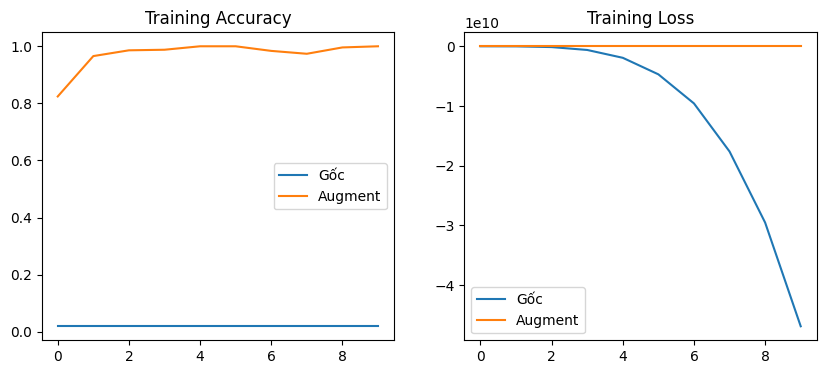

In [21]:
# Nguyễn Hoàng Tùng
# Bài 2.3

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# =======================
# 1️⃣ Tạo ImageDataGenerator cho 2 tập
# =======================
train_datagen = ImageDataGenerator(rescale=1./255)  # chuẩn hóa ảnh

# Tập dữ liệu gốc
train_data_original = train_datagen.flow_from_directory(
    r"C:/DATA",
    target_size=(150, 150),
    batch_size=8,
    class_mode='binary'
)

# Tập dữ liệu augment
train_data_aug = train_datagen.flow_from_directory(
    r"C:/DATA/hoa_aug",
    target_size=(150, 150),
    batch_size=8,
    class_mode='binary'
)

# =======================
# 2️⃣ Xây dựng mô hình CNN (5 lớp)
# =======================
def create_cnn_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# =======================
# 3️⃣ Huấn luyện trên tập gốc
# =======================
model_original = create_cnn_model()
history_original = model_original.fit(
    train_data_original,
    epochs=10,
    verbose=1
)

# =======================
# 4️⃣ Huấn luyện trên tập augment
# =======================
model_aug = create_cnn_model()
history_aug = model_aug.fit(
    train_data_aug,
    epochs=10,
    verbose=1
)

# =======================
# 5️⃣ So sánh kết quả
# =======================
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Biểu đồ Accuracy
plt.subplot(1,2,1)
plt.plot(history_original.history['accuracy'], label='Gốc')
plt.plot(history_aug.history['accuracy'], label='Augment')
plt.title('Training Accuracy')
plt.legend()

# Biểu đồ Loss
plt.subplot(1,2,2)
plt.plot(history_original.history['loss'], label='Gốc')
plt.plot(history_aug.history['loss'], label='Augment')
plt.title('Training Loss')
plt.legend()

plt.show()


Found 347 images belonging to 2 classes.
Found 148 images belonging to 2 classes.
Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step - accuracy: 0.7406 - loss: 0.7008 - val_accuracy: 0.8311 - val_loss: 0.3338
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.8646 - loss: 0.2461 - val_accuracy: 0.9797 - val_loss: 0.1328
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 226ms/step - accuracy: 0.9597 - loss: 0.1336 - val_accuracy: 0.9459 - val_loss: 0.1556
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 226ms/step - accuracy: 0.9885 - loss: 0.0548 - val_accuracy: 0.9865 - val_loss: 0.0333
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 226ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 0.9797 - val_loss: 0.0505
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 232ms/step - accuracy: 1.0000 - loss: 8.8433e-04 - val_accuracy: 0.9797 - val_loss: 0.0303
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 234ms/step - accuracy: 0.9971 - loss: 0.0054 - val_accuracy: 0.9662 - val_loss: 0.0680
Epoch 8/15


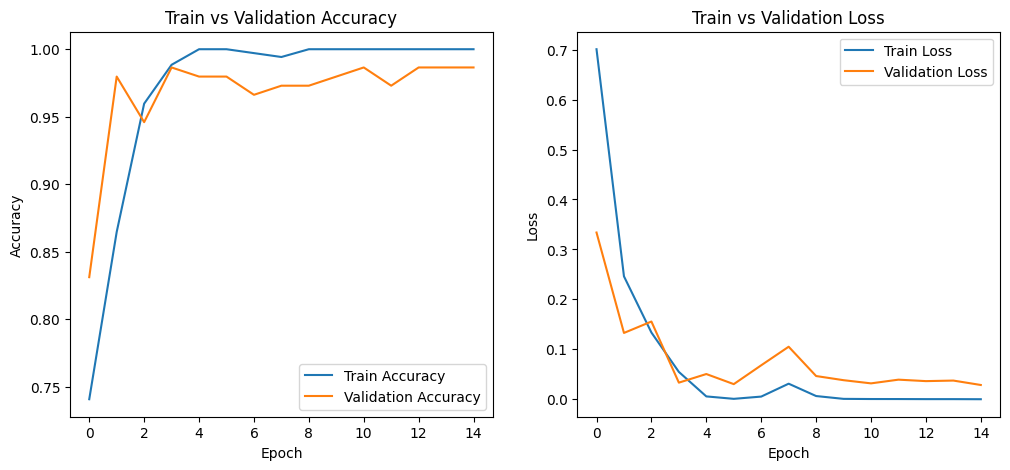

In [22]:
# Nguyễn Hoàng Tùng
# Bài 2.4

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# =======================
# 1️⃣ Chuẩn bị dữ liệu train/validation
# =======================
# Tạo generator cho train và validation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3  # 70% train - 30% validation
)

train_generator = train_datagen.flow_from_directory(
    r"C:/DATA/hoa_aug",       # dùng tập augment để tránh overfit
    target_size=(150, 150),
    batch_size=8,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    r"C:/DATA/hoa_aug",
    target_size=(150, 150),
    batch_size=8,
    class_mode='binary',
    subset='validation'
)

# =======================
# 2️⃣ Định nghĩa mô hình CNN
# =======================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# =======================
# 3️⃣ Huấn luyện và lưu lịch sử
# =======================
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    verbose=1
)

# =======================
# 4️⃣ Vẽ biểu đồ loss và accuracy
# =======================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Train vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


Found 347 images belonging to 2 classes.
Found 148 images belonging to 2 classes.
Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - accuracy: 0.8012 - loss: 0.4222 - val_accuracy: 0.9730 - val_loss: 0.0852
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 241ms/step - accuracy: 0.9827 - loss: 0.0468 - val_accuracy: 0.9527 - val_loss: 0.0764
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 239ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.9662 - val_loss: 0.1007
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 225ms/step - accuracy: 0.9971 - loss: 0.0121 - val_accuracy: 0.9595 - val_loss: 0.0676
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 246ms/step - accuracy: 0.9798 - loss: 0.0449 - val_accuracy: 0.9324 - val_loss: 0.1494
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 244ms/step - accuracy: 0.9280 - loss: 0.2010 - val_accuracy: 0.9324 - val_loss: 0.1636
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 226ms/step - accuracy: 0.9914 - loss: 0.0325 - val_accuracy: 0.9730 - val_loss: 0.0636
Epoch 8/15
44/4

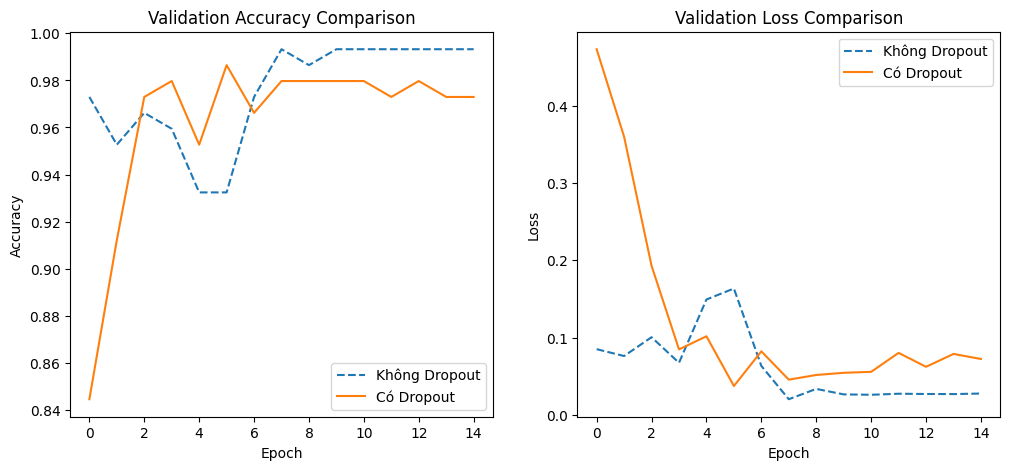

In [23]:
# Nguyễn Hoàng Tùng
# Bài 2.5

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# =======================
# 1️⃣ Chuẩn bị dữ liệu train/validation (dùng augment)
# =======================
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3  # 70% train - 30% val
)

train_gen = datagen.flow_from_directory(
    r"C:/DATA/hoa_aug",
    target_size=(150,150),
    batch_size=8,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    r"C:/DATA/hoa_aug",
    target_size=(150,150),
    batch_size=8,
    class_mode='binary',
    subset='validation'
)

# =======================
# 2️⃣ Hàm tạo mô hình không Dropout
# =======================
def build_cnn_no_dropout():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =======================
# 3️⃣ Hàm tạo mô hình có Dropout
# =======================
def build_cnn_with_dropout():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
        MaxPooling2D(2,2),
        Dropout(0.25),               # Giảm overfit sớm
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),                # Giảm overfit ở lớp fully connected
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =======================
# 4️⃣ Huấn luyện hai mô hình
# =======================
model_no_dropout = build_cnn_no_dropout()
history_no_dropout = model_no_dropout.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    verbose=1
)

model_with_dropout = build_cnn_with_dropout()
history_with_dropout = model_with_dropout.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    verbose=1
)

# =======================
# 5️⃣ So sánh biểu đồ Accuracy & Loss
# =======================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_no_dropout.history['val_accuracy'], label='Không Dropout', linestyle='--')
plt.plot(history_with_dropout.history['val_accuracy'], label='Có Dropout')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_no_dropout.history['val_loss'], label='Không Dropout', linestyle='--')
plt.plot(history_with_dropout.history['val_loss'], label='Có Dropout')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
